# K-Means - H&M (extended)


Evaluación del número de clusters y ajuste final del modelo. Se comparan las métricas internas y se analizan los perfiles obtenidos para las configuraciones seleccionadas.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import kmeans_metrics, plot_clustering_metrics, analyze_clusters, fit_clustering_model, save_clustering_metrics
import pandas as pd
import time

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/hym_scaled.csv")

In [3]:
# Variables utilizadas para clustering
X = df_scaled.drop(columns=["customer_id"], errors="ignore")

## Evaluación del número de clusters


In [4]:
resultados_kmeans = kmeans_metrics(X)

In [5]:
tabla_metricas = save_clustering_metrics(
    resultados_kmeans,
    model_name="kmeans",
    dataset_name="hym",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

Métricas consolidadas en ../../../results/clustering_metrics.csv


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,minibatch,instacart,simple,6,0.287861,92542.785246,1.110500,191238.961903,0.476716,NaN,NaN,NaN,NaN,NaN,NaN
248,minibatch,instacart,simple,7,0.287363,88688.845444,1.083745,173472.413504,0.090507,NaN,NaN,NaN,NaN,NaN,NaN
249,minibatch,instacart,simple,8,0.284887,90539.561492,1.089686,152061.334109,0.358054,NaN,NaN,NaN,NaN,NaN,NaN
250,minibatch,instacart,simple,9,0.282639,87440.639855,1.070433,140993.880428,0.330287,NaN,NaN,NaN,NaN,NaN,NaN


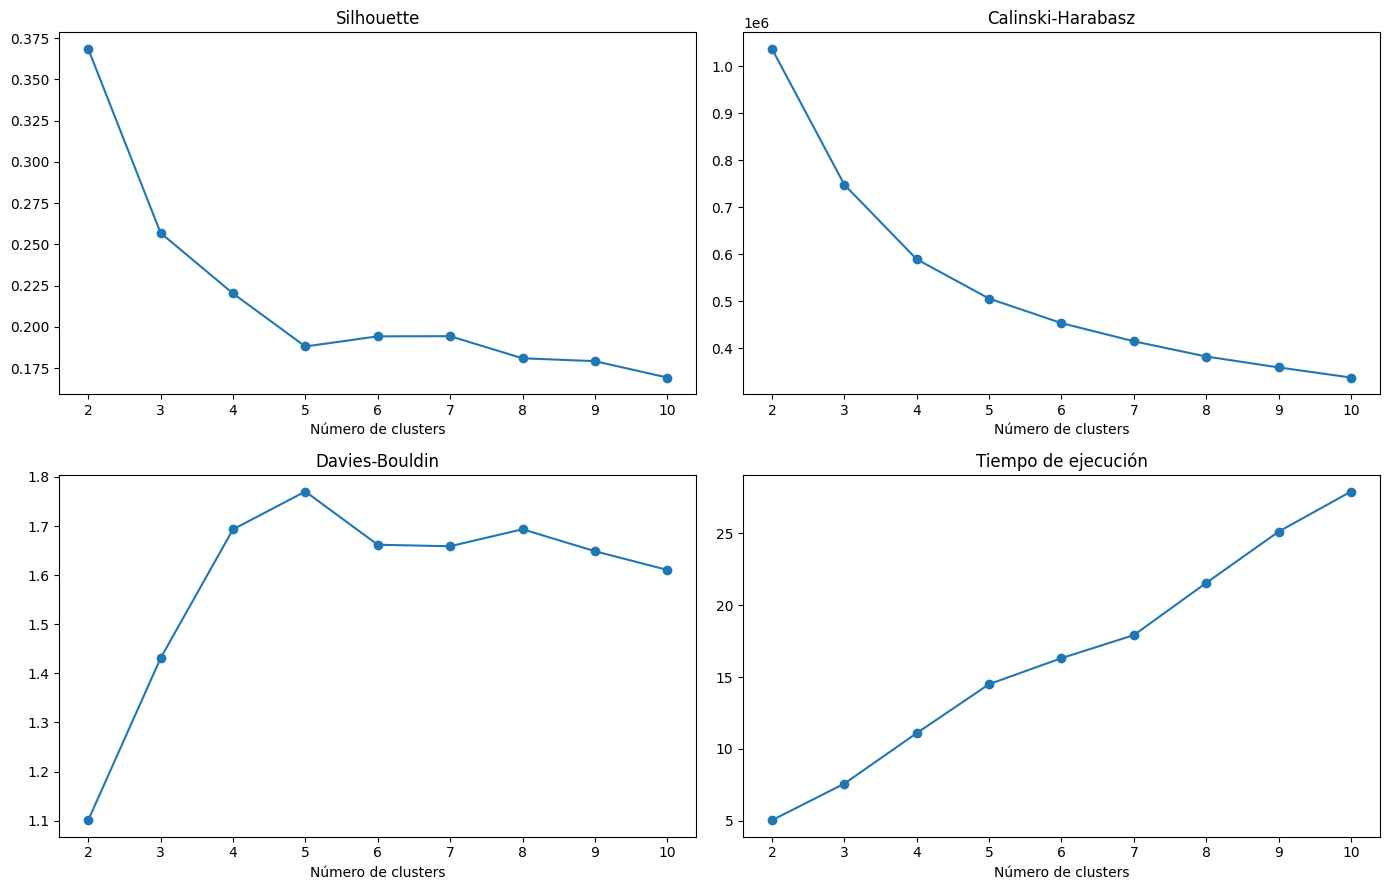

In [6]:
plot_clustering_metrics(resultados_kmeans)

In [7]:
df_original = pd.read_csv("../../../extended_datasets/hym_model_extended.csv")

## Ajuste final y perfil de los clusters


In [8]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=2,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_original,
    id_col="customer_id"
)



print(f"K-MEANS CON k = {2}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)

K-MEANS CON k = 2

Tamaño de los clusters:


cluster
0    712874
1    649407
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    52.33
1    47.67
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,monetary,avg_basket_size,std_basket_size,avg_price,std_price,avg_days_between_purchases,std_days_between_purchases,unique_articles,unique_product_types,unique_product_groups,unique_sections,unique_garment_groups,article_variety_ratio,channel_2_ratio
cluster,,,,,,,,,,,,,,,,
0,121.096,11.431,1.141,3.898,2.596,0.028,0.015,80.864,68.066,35.066,12.379,5.223,9.813,8.913,0.888,0.628
1,362.445,1.434,0.110,3.073,0.324,0.030,0.008,38.420,6.087,3.555,2.400,1.788,2.115,2.140,0.923,0.701


- Cluster 0 – Clientes ocasionales o inactivos: agrupa a clientes con una frecuencia de compra muy baja y una recencia elevada, por lo que llevan bastante tiempo sin realizar una compra. Presentan un gasto reducido, cestas pequeñas y una variedad absoluta muy limitada de artículos, tipos de producto, secciones y grupos de prendas. Su article_variety_ratio es muy elevado, lo que indica que, aunque compran pocos artículos, tienden a repetirlos poco.
- Cluster 1 – Clientes activos y de alto valor: corresponde a clientes con una frecuencia de compra considerablemente mayor y una recencia mucho menor. Presentan un gasto total claramente superior, cestas ligeramente mayores y compran una variedad mucho más amplia de artículos, tipos de producto, grupos, secciones y categorías de prendas. Representan, por tanto, el segmento con una relación más intensa y continuada con H&M.

In [9]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=3,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_original,
    id_col="customer_id"
)

print(f"K-MEANS CON k = {3}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)


K-MEANS CON k = 3

Tamaño de los clusters:


cluster
0    443259
1    508671
2    410351
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    32.54
1    37.34
2    30.12
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,monetary,avg_basket_size,std_basket_size,avg_price,std_price,avg_days_between_purchases,std_days_between_purchases,unique_articles,unique_product_types,unique_product_groups,unique_sections,unique_garment_groups,article_variety_ratio,channel_2_ratio
cluster,,,,,,,,,,,,,,,,
0,209.136,4.104,0.306,3.249,1.732,0.028,0.014,125.275,68.022,10.065,5.762,3.346,4.856,4.849,0.902,0.621
1,386.657,1.140,0.092,3.101,0.075,0.030,0.007,8.735,0.107,2.969,2.055,1.591,1.821,1.847,0.928,0.710
2,78.756,16.282,1.712,4.282,3.058,0.028,0.016,55.132,54.269,51.992,16.532,6.316,12.892,11.343,0.879,0.648


- Cluster 0 – Clientes activos y de alto valor: presentan la menor recencia y, con diferencia, la mayor frecuencia de compra y gasto total. Realizan cestas relativamente grandes y compran una variedad muy elevada de artículos, tipos de producto, secciones y grupos de prendas. Representan el segmento con mayor actividad y vinculación con H&M.
- Cluster 1 – Clientes prácticamente inactivos: presentan la mayor recencia y una frecuencia cercana a una única compra. Su gasto es muy reducido y adquieren muy pocos artículos y categorías diferentes. El elevado article_variety_ratio indica que, aunque compran poco, tienden a repetir escasamente los mismos artículos.
- Cluster 2 – Clientes ocasionales de actividad intermedia: muestran una recencia y frecuencia situadas entre los otros dos grupos. Compran más veces y una mayor variedad de artículos que los clientes inactivos, pero se encuentran claramente por debajo del segmento activo en gasto, frecuencia y diversidad de productos. Representan clientes con una relación ocasional con H&M, sin llegar a desarrollar un comportamiento de compra recurrente.

In [10]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=4,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_original,
    id_col="customer_id"
)

print(f"K-MEANS CON k = {4}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)

K-MEANS CON k = 4

Tamaño de los clusters:


cluster
0    409316
1    285892
2    430226
3    236847
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    30.05
1    20.99
2    31.58
3    17.39
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,monetary,avg_basket_size,std_basket_size,avg_price,std_price,avg_days_between_purchases,std_days_between_purchases,unique_articles,unique_product_types,unique_product_groups,unique_sections,unique_garment_groups,article_variety_ratio,channel_2_ratio
cluster,,,,,,,,,,,,,,,,
0,79.321,16.291,1.715,4.281,3.075,0.028,0.016,55.173,54.132,52.078,16.546,6.318,12.903,11.349,0.878,0.650
1,372.602,1.148,0.056,1.599,0.051,0.033,0.002,11.325,0.185,1.621,1.289,1.160,1.218,1.204,0.936,0.771
2,200.610,4.206,0.304,3.017,1.729,0.028,0.014,129.876,70.337,10.031,5.758,3.343,4.853,4.844,0.904,0.619
3,407.019,1.159,0.151,5.351,0.186,0.027,0.012,3.797,0.018,5.113,3.230,2.229,2.750,2.827,0.915,0.633


- Cluster 0 – Clientes activos y de alto valor: agrupa a los clientes con mayor frecuencia de compra, menor recencia y mayor gasto total. Realizan cestas relativamente grandes y presentan, con mucha diferencia, la mayor variedad absoluta de artículos, tipos de producto, secciones y grupos de prendas. Representan el segmento con mayor actividad y vinculación con H&M.
- Cluster 1 – Clientes ocasionales de actividad moderada: presentan una frecuencia de compra considerablemente inferior y llevan más tiempo sin comprar que los clientes del cluster 0. Su gasto, tamaño de cesta y variedad de artículos son también notablemente menores. Se trata de clientes que han realizado varias compras, pero mantienen una relación más esporádica con la empresa.
- Cluster 2 – Clientes prácticamente inactivos de compra mínima: muestran una recencia muy elevada y una frecuencia cercana a una única compra. Sus cestas son muy pequeñas y adquieren prácticamente un único artículo, perteneciente a muy pocas categorías. Presentan el mayor article_variety_ratio, debido principalmente a que realizan tan pocas compras que apenas tienen oportunidad de repetir artículos.
- Cluster 3 – Clientes inactivos de compra puntual grande: presentan también una frecuencia cercana a una única compra y la peor recencia de los cuatro grupos, pero se diferencian del cluster 2 porque realizan cestas considerablemente mayores y compran más artículos y categorías en esa compra. Representan clientes que realizaron una compra puntual relativamente grande, pero que posteriormente no mantuvieron una relación recurrente con H&M.